In [1]:
from PIL import Image
import numpy as np

# Create a simple 100x100 colorful image
img = Image.new('RGB', (100, 100))
pixels = []

for i in range(100):
    for j in range(100):
        # Gradient colors
        pixels.append((i * 2, j * 2, 100))

img.putdata(pixels)
img.save('cover_image.png')
print("Cover image created!")

# Show image info
print(f"Size: {img.size}")
print(f"Mode: {img.mode}")
print(f"Total pixels: {img.size[0] * img.size[1]}")

Cover image created!
Size: (100, 100)
Mode: RGB
Total pixels: 10000


In [2]:
def encode_message(image_path, secret_message):
    img = Image.open(image_path)
    pixels = list(img.getdata())
    
    # Convert message to binary
    secret_message += "<<END>>"  # Marker to know where message ends
    binary_message = ''.join(format(ord(c), '08b') for c in secret_message)
    
    print(f"Secret message:       {secret_message}")
    print(f"Message in binary:    {binary_message[:40]}...")
    print(f"Total bits to hide:   {len(binary_message)}")
    print(f"Available pixels:     {len(pixels)}")
    
    # Hide each bit in LSB of each pixel's R channel
    new_pixels = []
    bit_index = 0
    
    for pixel in pixels:
        r, g, b = pixel
        if bit_index < len(binary_message):
            # Replace last bit of R with our secret bit
            r = (r & ~1) | int(binary_message[bit_index])
            bit_index += 1
        new_pixels.append((r, g, b))
    
    # Save encoded image
    encoded_img = Image.new('RGB', img.size)
    encoded_img.putdata(new_pixels)
    encoded_img.save('encoded_image.png')
    print(f"\nMessage hidden successfully!")
    print(f"Encoded image saved as: encoded_image.png")

# Hide your secret!
encode_message('cover_image.png', 'Quantum is the future!')

Secret message:       Quantum is the future!<<END>>
Message in binary:    0101000101110101011000010110111001110100...
Total bits to hide:   232
Available pixels:     10000

Message hidden successfully!
Encoded image saved as: encoded_image.png


/tmp/ipykernel_7120/1057638645.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())


In [3]:
def decode_message(image_path):
    img = Image.open(image_path)
    pixels = list(img.get_flattened_data())  # Fixed — no deprecation warning
    
    # Extract LSB from R channel of each pixel
    binary_message = ""
    for i in range(0, len(pixels), 3):  # Every 3 values = one RGB pixel
        r = pixels[i]
        binary_message += str(r & 1)    # Extract last bit
    
    # Convert binary back to text
    chars = []
    for i in range(0, len(binary_message), 8):
        byte = binary_message[i:i+8]
        if len(byte) == 8:
            chars.append(chr(int(byte, 2)))
    
    # Find end marker
    full_text = ''.join(chars)
    if "<<END>>" in full_text:
        secret = full_text[:full_text.index("<<END>>")]
        print(f"Hidden message found: {secret}")
    else:
        print("No hidden message found!")

# Decode the secret!
decode_message('encoded_image.png')

TypeError: unsupported operand type(s) for &: 'tuple' and 'int'

In [4]:
def decode_message(image_path):
    img = Image.open(image_path)
    pixels = list(img.getdata())  # Returns list of (R,G,B) tuples
    
    # Extract LSB from R channel of each pixel
    binary_message = ""
    for pixel in pixels:
        r = pixel[0]                    # Get R value from tuple
        binary_message += str(r & 1)   # Extract last bit
    
    # Convert binary back to text
    chars = []
    for i in range(0, len(binary_message), 8):
        byte = binary_message[i:i+8]
        if len(byte) == 8:
            chars.append(chr(int(byte, 2)))
    
    # Find end marker
    full_text = ''.join(chars)
    if "<<END>>" in full_text:
        secret = full_text[:full_text.index("<<END>>")]
        print(f"Hidden message found: {secret}")
    else:
        print("No hidden message found!")

# Decode the secret!
decode_message('encoded_image.png')

Hidden message found: Quantum is the future!


/tmp/ipykernel_7120/2832263165.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())  # Returns list of (R,G,B) tuples


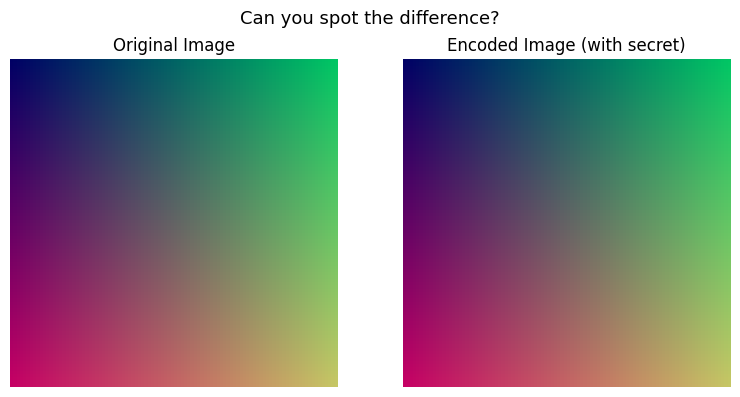

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

# Load both images
original = Image.open('cover_image.png')
encoded  = Image.open('encoded_image.png')

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(original)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(encoded)
axes[1].set_title('Encoded Image (with secret)')
axes[1].axis('off')

plt.suptitle('Can you spot the difference?', fontsize=13)
plt.tight_layout()
plt.show()